# Баллистика с линейным сопротивлением
## Задание 1.2 · зелёный уровень

Рассмотрим бросок с поверхности земли под углом к горизонту. Сравним два способа численного расчёта с аналитическим решением, проверим влияние шага и посмотрим, как сопротивление меняет траекторию и энергию.

Ось $y$ направлена вверх. Для состояния $q=(x,y,v_x,v_y)$ уравнения имеют вид
$$\dot q=(v_x,v_y,-v_x/\tau,-g-v_y/\tau).$$
Чем меньше положительное время торможения $\tau$, тем сильнее сопротивление при одной и той же скорости.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
colors = {"Эйлер": "#d97732", "RK4": "#147d92"}
g, mass = 9.81, 1.0
speed, angle = 30.0, np.deg2rad(40.0)
initial = np.array([0.0, 0.0, speed*np.cos(angle), speed*np.sin(angle)])
tau_main = 3.0
print("Начальная скорость: 30 м/с; угол: 40°; масса: 1 кг; τ = 3 с.")

Начальная скорость: 30 м/с; угол: 40°; масса: 1 кг; τ = 3 с.


### 1. Точное решение

Из уравнения для горизонтальной скорости получаем экспоненциальное затухание. Для вертикальной скорости сначала вычтем установившееся значение $-g\tau$. Интегрирование скоростей даёт координаты:
$$v_x=v_{x0}e^{-t/\tau},\qquad v_y=(v_{y0}+g\tau)e^{-t/\tau}-g\tau,$$
$$x=x_0+\tau v_{x0}(1-e^{-t/\tau}),$$
$$y=y_0+\tau(v_{y0}+g\tau)(1-e^{-t/\tau})-g\tau t.$$

Для сравнения все методы считаем до одного времени $T$ — положительного корня аналитического уравнения $y(T)=0$. Корень найдём делением отрезка пополам между вершиной траектории и точкой ниже земли.

In [2]:
def exact(t, tau):
    t = np.asarray(t, dtype=float)
    x0, y0, u0, w0 = initial
    if np.isinf(tau):
        return np.stack((x0 + u0*t, y0 + w0*t - g*t*t/2,
                         np.full_like(t, u0), w0-g*t), axis=-1)
    decay = np.exp(-t/tau)
    integral = -tau*np.expm1(-t/tau)
    return np.stack((x0 + u0*integral,
                     y0 + (w0+g*tau)*integral - g*tau*t,
                     u0*decay, (w0+g*tau)*decay-g*tau), axis=-1)

def flight_time(tau):
    # Для заданного броска с y0 = 0 и vy0 > 0.
    if np.isinf(tau):
        return 2*initial[3]/g
    left = tau*np.log1p(initial[3]/(g*tau))  # время вершины
    right = 2*initial[3]/g
    while exact(right, tau)[1] > 0:
        right *= 2
    for _ in range(60):
        middle = (left+right)/2
        if exact(middle, tau)[1] > 0:
            left = middle
        else:
            right = middle
    return (left+right)/2

T = flight_time(tau_main)
print(f"Время полёта по точной формуле: {T:.4f} с")
print(f"Дальность по точной формуле: {exact(T, tau_main)[0]:.4f} м")

Время полёта по точной формуле: 3.3283 с
Дальность по точной формуле: 46.2098 м


### 2. Численный расчёт

Явный метод Эйлера использует наклон в начале шага: $q_{n+1}=q_n+h f(q_n)$.
В классическом RK4 используются четыре оценки:
$$k_1=f(q_n),\quad k_2=f(q_n+hk_1/2),\quad k_3=f(q_n+hk_2/2),\quad k_4=f(q_n+hk_3),$$
$$q_{n+1}=q_n+\frac h6(k_1+2k_2+2k_3+k_4).$$

Равномерная сетка задаётся числом интервалов $N$, поэтому фактический шаг точно равен $h=T/N$. Все компоненты в методе Эйлера обновляются по старому состоянию.

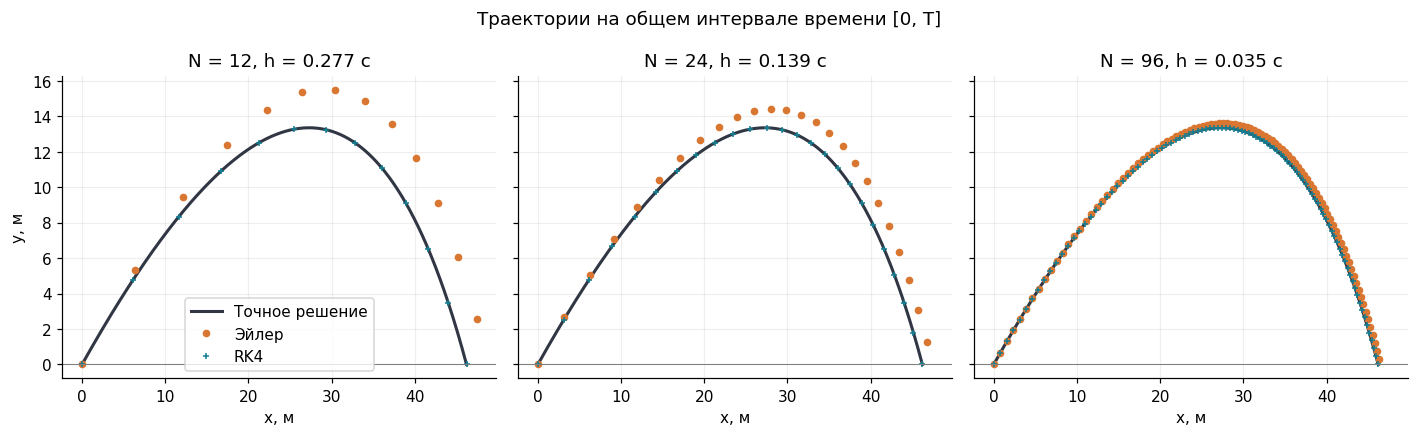

In [3]:
def rhs(q, tau):
    return np.array([q[2], q[3], -q[2]/tau, -g-q[3]/tau])

def solve(method, intervals, end=T, tau=tau_main):
    times = np.linspace(0, end, intervals+1)
    h = end/intervals
    states = np.empty((intervals+1, 4))
    states[0] = initial
    for i in range(intervals):
        q = states[i]
        a = rhs(q, tau)
        if method == "Эйлер":
            states[i+1] = q + h*a
        elif method == "RK4":
            b = rhs(q+h*a/2, tau)
            c = rhs(q+h*b/2, tau)
            d = rhs(q+h*c, tau)
            states[i+1] = q + h*(a+2*b+2*c+d)/6
        else:
            raise ValueError("Неизвестный метод")
    return times, states

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
dense = exact(np.linspace(0, T, 500), tau_main)
for ax, n in zip(axes, [12, 24, 96]):
    ax.plot(dense[:, 0], dense[:, 1], color="#303643", lw=2, label="Точное решение")
    for method in colors:
        t, q = solve(method, n)
        ax.plot(q[:, 0], q[:, 1], linestyle="none", marker="o" if method == "Эйлер" else "+",
                markersize=4, color=colors[method], label=method)
    ax.set(title=f"N = {n}, h = {T/n:.3f} с", xlabel="x, м")
    ax.axhline(0, color="gray", lw=0.7)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("y, м")
axes[0].legend()
fig.suptitle("Траектории на общем интервале времени [0, T]")
fig.tight_layout()
plt.show()

Точки RK4 практически лежат на точной кривой. На грубой сетке Эйлер заметно завышает высоту. Конечная численная точка не обязана лежать на земле: расчёт заканчивается в точное время $T$, а отклонение по высоте отражает ошибку метода.

### 3. Влияние шага

Измерим максимальную ошибку положения на узлах сетки:
$$\varepsilon_h=\max_n\|\mathbf r_n-\mathbf r_{\mathrm{точн}}(t_n)\|_2.$$
Оценка порядка при делении шага пополам: $p=\log_2(\varepsilon_h/\varepsilon_{h/2})$. Ожидаем приближение к 1 для Эйлера и к 4 для RK4.

Выведем значения p и насколько оно близко лежит к прямой с наклоном 1 и 4 соответственно

Метод          h, с      Ошибка, м    Порядок
Эйлер       0.27736   2.857313e+00          —
Эйлер       0.13868   1.400912e+00      1.028
Эйлер       0.06934   6.936777e-01      1.014
Эйлер       0.03467   3.451495e-01      1.007
Эйлер       0.01733   1.721579e-01      1.003
RK4         0.27736   3.908706e-05          —
RK4         0.13868   2.350475e-06      4.056
RK4         0.06934   1.441178e-07      4.028
RK4         0.03467   8.921035e-09      4.014
RK4         0.01733   5.548838e-10      4.007


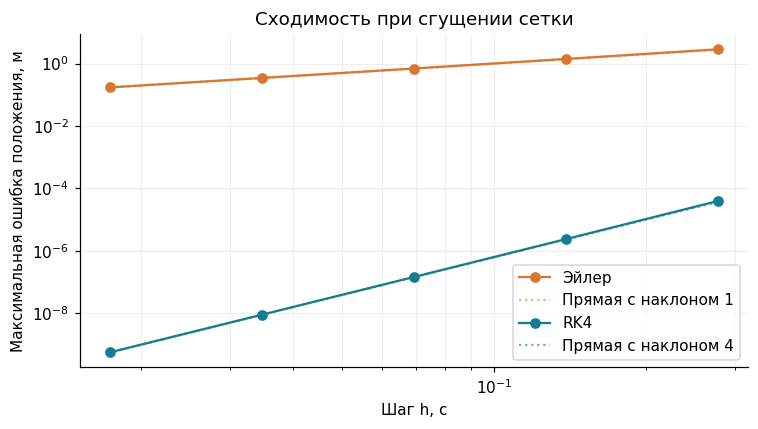

In [4]:
counts = np.array([12, 24, 48, 96, 192])
steps = T/counts
errors = {}
print(f"{'Метод':<8} {'h, с':>10} {'Ошибка, м':>14} {'Порядок':>10}")
for method in colors:
    values = []
    for n in counts:
        t, q = solve(method, n)
        values.append(np.linalg.norm(q[:, :2]-exact(t, tau_main)[:, :2], axis=1).max())
    errors[method] = np.array(values)
    orders = np.log2(errors[method][:-1]/errors[method][1:])
    for i, (h, error) in enumerate(zip(steps, values)):
        order_text = "—" if i == 0 else f"{orders[i-1]:.3f}"
        print(f"{method:<8} {h:10.5f} {error:14.6e} {order_text:>10}")

fig, ax = plt.subplots(figsize=(7, 4))
for method, order in [("Эйлер", 1), ("RK4", 4)]:
    ax.loglog(steps, errors[method], "o-", color=colors[method], label=method)
    ax.loglog(steps, errors[method][-1]*(steps/steps[-1])**order,
              ":", color=colors[method], alpha=0.6, label=f"Прямая с наклоном {order}")
ax.set(xlabel="Шаг h, с", ylabel="Максимальная ошибка положения, м", title="Сходимость при сгущении сетки")
ax.grid(which="both", alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

Из графика можно сказать, что точки практически лежат на прямой

### 4. Механическая энергия

Нулевой уровень потенциальной энергии выбран на земле:
$$U=mgy,\qquad K=\frac m2(v_x^2+v_y^2),\qquad E=U+K.$$
Из уравнений движения следует
$$\frac{dE}{dt}=-\frac m\tau(v_x^2+v_y^2)\leq0.$$
Поэтому уменьшение полной энергии здесь физически закономерно. На графиках сравним обе численные схемы с точными значениями.

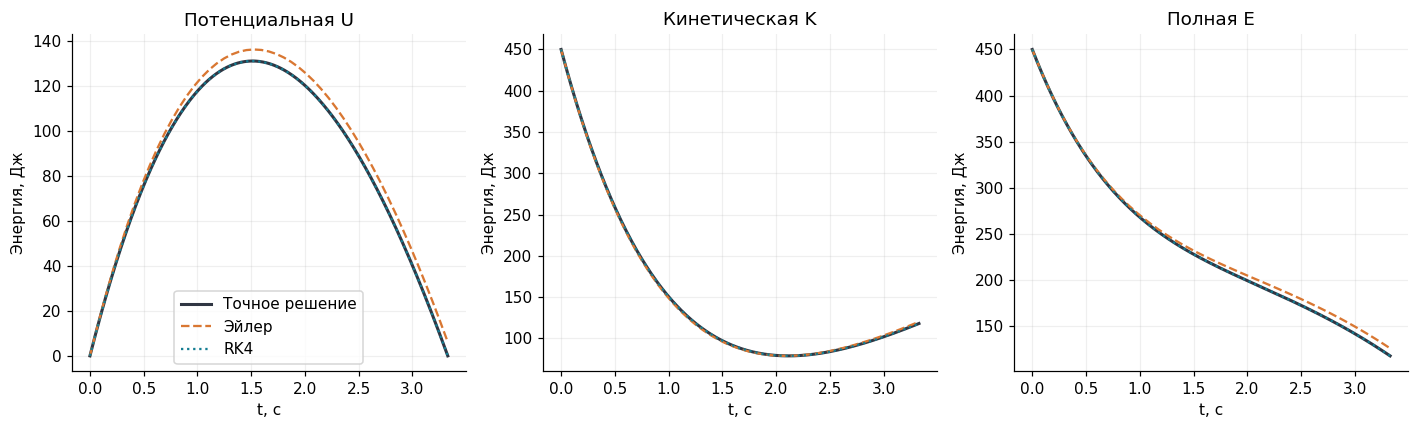

Полная энергия: 450.00 → 118.05 Дж.
За время полёта потеряно 73.8% начальной энергии.


In [5]:
def energy(q):
    potential = mass*g*q[:, 1]
    kinetic = mass*np.sum(q[:, 2:]**2, axis=1)/2
    return potential, kinetic, potential+kinetic

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
times = np.linspace(0, T, 500)
for ax, title, exact_values in zip(axes, ["Потенциальная U", "Кинетическая K", "Полная E"], energy(exact(times, tau_main))):
    ax.plot(times, exact_values, color="#303643", lw=2, label="Точное решение")
    ax.set(title=title, xlabel="t, с", ylabel="Энергия, Дж")
    ax.grid(alpha=0.2)
for method in colors:
    t, q = solve(method, 48)
    for ax, values in zip(axes, energy(q)):
        ax.plot(t, values, "--" if method == "Эйлер" else ":", color=colors[method], label=method)
axes[0].legend()
fig.tight_layout()
plt.show()
e_start, e_finish = energy(exact(np.array([0, T]), tau_main))[2]
print(f"Полная энергия: {e_start:.2f} → {e_finish:.2f} Дж.")
print(f"За время полёта потеряно {100*(1-e_finish/e_start):.1f}% начальной энергии.")

### 5. Влияние сопротивления

Оставим начальные условия прежними и изменим только $\tau$. Для каждого случая построим точную траекторию до земли и точки RK4 на сетке из 96 интервалов. Отдельно добавим движение без сопротивления ($\tau\to\infty$).

        τ, с     Время, с    Дальность, м     Высота, м
         0.8       2.6671         17.7296        7.6389
         1.5       2.9952         29.7917       10.4408
           3       3.3283         46.2098       13.3576
           8       3.6542         67.4138       16.3271
           ∞       3.9314         90.3493       18.9530


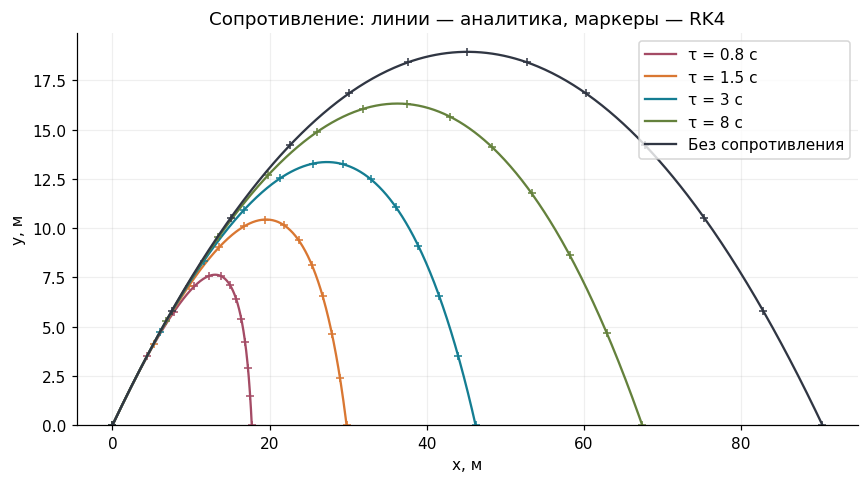

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
print(f"{'τ, с':>12} {'Время, с':>12} {'Дальность, м':>15} {'Высота, м':>13}")
for tau, color in zip([0.8, 1.5, 3.0, 8.0, np.inf], ["#a44b65", "#d97732", "#147d92", "#64813c", "#303643"]):
    end = flight_time(tau)
    q_ref = exact(np.linspace(0, end, 500), tau)
    label = "Без сопротивления" if np.isinf(tau) else f"τ = {tau:g} с"
    ax.plot(q_ref[:, 0], q_ref[:, 1], color=color, label=label)
    _, q_num = solve("RK4", 96, end=end, tau=tau)
    ax.plot(q_num[::8, 0], q_num[::8, 1], "+", color=color, markersize=5)
    top_time = initial[3]/g if np.isinf(tau) else tau*np.log1p(initial[3]/(g*tau))
    name = "∞" if np.isinf(tau) else f"{tau:g}"
    print(f"{name:>12} {end:12.4f} {q_ref[-1, 0]:15.4f} {exact(top_time, tau)[1]:13.4f}")
ax.set(xlabel="x, м", ylabel="y, м", title="Сопротивление: линии — аналитика, маркеры — RK4")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

### Выводы

1. Оба метода приближаются к точному решению при уменьшении шага. В таблице оценки порядка близки к 1 для Эйлера и к 4 для RK4: при делении шага пополам ошибка уменьшается примерно в 2 и 16 раз соответственно.
2. Для выбранных начальных условий усиление сопротивления (уменьшение $\tau$) сокращает дальность, максимальную высоту и время полёта. Горизонтальная скорость убывает, поэтому траектория перестаёт быть симметричной параболой.
3. Потенциальная энергия растёт при подъёме и убывает при спуске. Кинетическая сначала уменьшается, затем увеличивается на части спуска. Её минимум не обязан совпадать с вершиной: сопротивление продолжает тормозить горизонтальное движение и при $v_y=0$.
4. Полная механическая энергия убывает из-за работы сопротивления. RK4 хорошо воспроизводит аналитические графики уже на умеренной сетке; погрешность Эйлера заметнее.
